<a href="https://colab.research.google.com/github/sashanksiriki/lung-cancer-detection/blob/main/lung_cancer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Stage 1 - Loading the dataset

In [ ]:
import os

# Set the environment variable
os.environ['KAGGLE_API_TOKEN'] = "KGAT_3c8bd71f09764977f3156e35c67ef01d"

# Install/verify kaggle CLI
!pip install -q kaggle

KGAT_3c8bd71f09764977f3156e35c67ef01d

In [ ]:
!kaggle datasets download -d adityamahimkar/iqothnccd-lung-cancer-dataset -p /content/data
!unzip -q /content/data/iqothnccd-lung-cancer-dataset.zip -d /content/data/iqothnccd

Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
100% 199M/199M [00:02<00:00, 83.7MB/s]



In [ ]:
import os

for root, dirs, files in os.walk('/content/data/iqothnccd'):
    level = root.replace('/content/data/iqothnccd', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level <= 2:  # avoid flooding output with every filename
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files total)')

iqothnccd/
  The IQ-OTHNCCD lung cancer dataset/
    The IQ-OTHNCCD lung cancer dataset/
      IQ-OTH_NCCD lung cancer dataset.txt
      Malignant cases/
      Normal cases/
      Bengin cases/
  Test cases/
    000247_05_01_178.png
    000103_03_01_166.png
    000103_03_01_082.png
    ... (197 files total)


In [ ]:
base = '/content/data/iqothnccd/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'

class_dirs = {
    'Normal': f'{base}/Normal cases',
    'Benign': f'{base}/Bengin cases',      # yes, misspelled in the actual dataset — keep it as-is
    'Malignant': f'{base}/Malignant cases',
}

import os
for cls, path in class_dirs.items():
    count = len(os.listdir(path))
    print(f'{cls}: {count} images')

Normal: 416 images
Benign: 120 images
Malignant: 561 images


In [ ]:
test_path = '/content/data/iqothnccd/Test cases'
print(len(os.listdir(test_path)))
print(os.listdir(test_path)[:5])

197
['000247_05_01_178.png', '000103_03_01_166.png', '000103_03_01_082.png', '000569_08_01_020.png', '000058_06_02_223.png']


In [ ]:
normal_files = set(os.listdir(class_dirs['Normal']))
benign_files = set(os.listdir(class_dirs['Benign']))
malignant_files = set(os.listdir(class_dirs['Malignant']))
test_files = set(os.listdir(test_path))

print("Overlap with Normal:", len(test_files & normal_files))
print("Overlap with Benign:", len(test_files & benign_files))
print("Overlap with Malignant:", len(test_files & malignant_files))

Overlap with Normal: 0
Overlap with Benign: 0
Overlap with Malignant: 0


In [ ]:
def patient_id(fname):
    return fname.split('_')[0]

test_patient_ids = set(patient_id(f) for f in test_files)
normal_ids = set(patient_id(f) for f in normal_files)
benign_ids = set(patient_id(f) for f in benign_files)
malignant_ids = set(patient_id(f) for f in malignant_files)

print("Test patient IDs matching Normal:", len(test_patient_ids & normal_ids))
print("Test patient IDs matching Benign:", len(test_patient_ids & benign_ids))
print("Test patient IDs matching Malignant:", len(test_patient_ids & malignant_ids))

Test patient IDs matching Normal: 0
Test patient IDs matching Benign: 0
Test patient IDs matching Malignant: 0


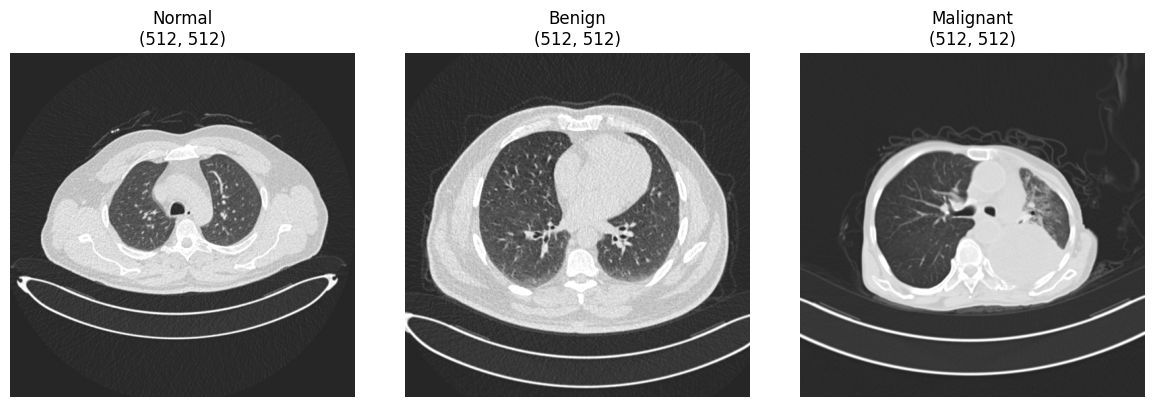

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (cls, path) in zip(axes, class_dirs.items()):
    sample_file = random.choice(os.listdir(path))
    img = Image.open(os.path.join(path, sample_file))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{cls}\n{img.size}')
    ax.axis('off')
plt.tight_layout()
plt.show()

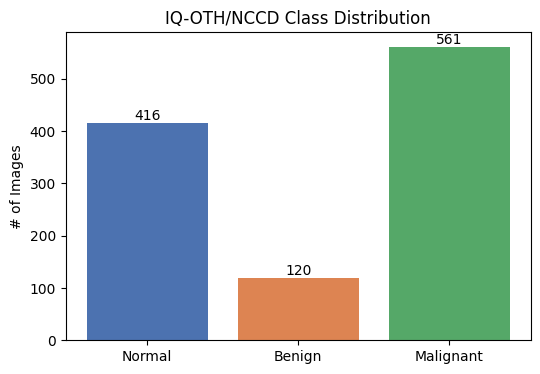

In [ ]:
counts = {cls: len(os.listdir(path)) for cls, path in class_dirs.items()}

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=['#4C72B0','#DD8452','#55A868'])
plt.title('IQ-OTH/NCCD Class Distribution')
plt.ylabel('# of Images')
for i, (k, v) in enumerate(counts.items()):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

#stage 2 - Image Enhancement

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Grab one sample image (use Malignant class for a clear example)
sample_path = os.path.join(class_dirs['Malignant'], os.listdir(class_dirs['Malignant'])[0])
img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
print("Shape:", img.shape, "Dtype:", img.dtype)

Shape: (512, 512) Dtype: uint8


In [ ]:
def apply_median_filter(image, ksize=5):
    return cv2.medianBlur(image, ksize)

def apply_histogram_equalization(image):
    return cv2.equalizeHist(image)

def apply_clahe(image, clip_limit=2.0, tile_size=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(image)

def apply_morphological(image, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(image, kernel, iterations=1)
    eroded = cv2.erode(dilated, kernel, iterations=1)  # closing (dilate→erode)
    return eroded

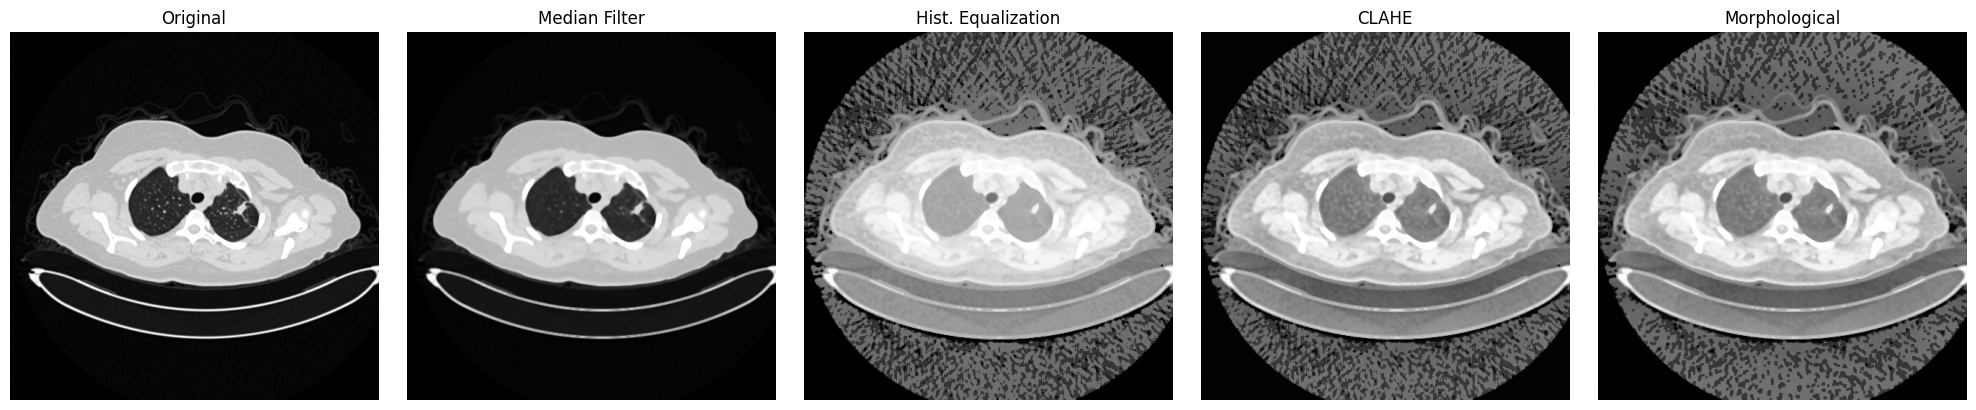

In [ ]:
step1 = apply_median_filter(img)
step2 = apply_histogram_equalization(step1)
step3 = apply_clahe(step2)
step4 = apply_morphological(step3)

stages = [img, step1, step2, step3, step4]
titles = ['Original', 'Median Filter', 'Hist. Equalization', 'CLAHE', 'Morphological']

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, im, title in zip(axes, stages, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def enhance_image(img):
    img = apply_median_filter(img)
    img = apply_histogram_equalization(img)
    img = apply_clahe(img)
    img = apply_morphological(img)
    return img

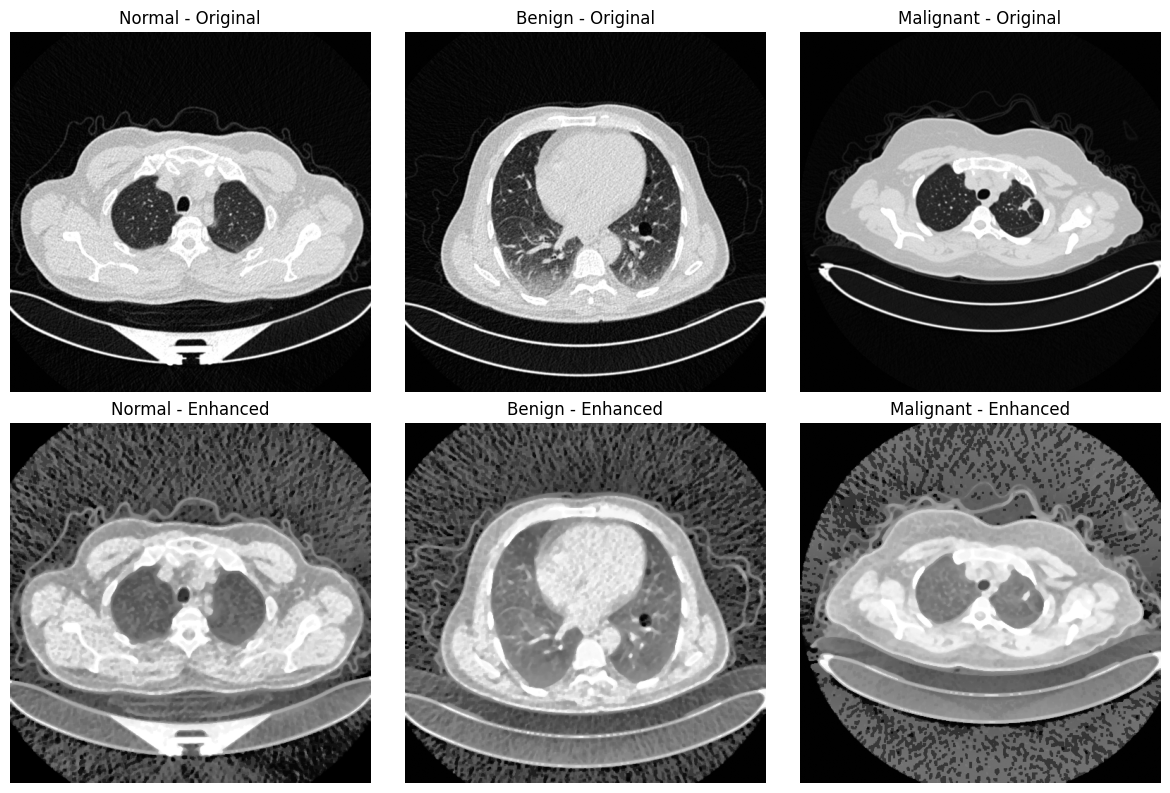

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for col, (cls, path) in enumerate(class_dirs.items()):
    sample_file = os.listdir(path)[0]
    raw = cv2.imread(os.path.join(path, sample_file), cv2.IMREAD_GRAYSCALE)
    enhanced = enhance_image(raw)

    axes[0, col].imshow(raw, cmap='gray')
    axes[0, col].set_title(f'{cls} - Original')
    axes[0, col].axis('off')

    axes[1, col].imshow(enhanced, cmap='gray')
    axes[1, col].set_title(f'{cls} - Enhanced')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

#stage 3 -Data Augmentation + training

In [ ]:
def preprocess_image(img, size=(224,224)):
    img = enhance_image(img)          # your Stage 2 pipeline
    img = cv2.resize(img, size)
    img = img.astype('float32') / 255.0   # rescale 0-1
    return img

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

def patient_id(fname):
    return os.path.basename(fname).split('_')[0]

# Build a dataframe of filepath, label, patient_id
records = []
for cls, path in class_dirs.items():
    for fname in os.listdir(path):
        records.append({
            'filepath': os.path.join(path, fname),
            'label': label_map[cls],
            'patient_id': patient_id(fname)
        })
df = pd.DataFrame(records)

# Get unique patients with their (majority) label
patient_labels = df.groupby('patient_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

# Split PATIENTS, not images
train_p, temp_p = train_test_split(patient_labels, test_size=0.3, stratify=patient_labels['label'], random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=(2/3), stratify=temp_p['label'], random_state=42)

train_df = df[df['patient_id'].isin(train_p['patient_id'])]
val_df   = df[df['patient_id'].isin(val_p['patient_id'])]
test_df  = df[df['patient_id'].isin(test_p['patient_id'])]

train_fp, train_lb = train_df['filepath'].tolist(), train_df['label'].tolist()
val_fp, val_lb     = val_df['filepath'].tolist(), val_df['label'].tolist()
test_fp, test_lb   = test_df['filepath'].tolist(), test_df['label'].tolist()

print(f"Train: {len(train_fp)} images, Val: {len(val_fp)}, Test: {len(test_fp)}")
print(f"Unique patients — Train: {train_df['patient_id'].nunique()}, Val: {val_df['patient_id'].nunique()}, Test: {test_df['patient_id'].nunique()}")

Train: 767 images, Val: 110, Test: 220
Unique patients — Train: 767, Val: 110, Test: 220


In [ ]:
import random

def augment_image(img):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)  # horizontal flip

    if random.random() > 0.5:
        img = cv2.flip(img, 0)  # vertical flip

    if random.random() > 0.5:
        rows, cols = img.shape
        shear_factor = random.uniform(-0.2, 0.2)
        M = np.float32([[1, shear_factor, 0], [0, 1, 0]])
        img = cv2.warpAffine(img, M, (cols, rows))

    return img

In [ ]:
def preprocess_train(img):
    img = enhance_image(img)      # Stage 2 pipeline
    img = augment_image(img)      # augmentation only for training
    img = cv2.resize(img, (224,224))
    img = img.astype('float32') / 255.0
    return img

def preprocess_eval(img):
    img = enhance_image(img)
    img = cv2.resize(img, (224,224))
    img = img.astype('float32') / 255.0
    return img

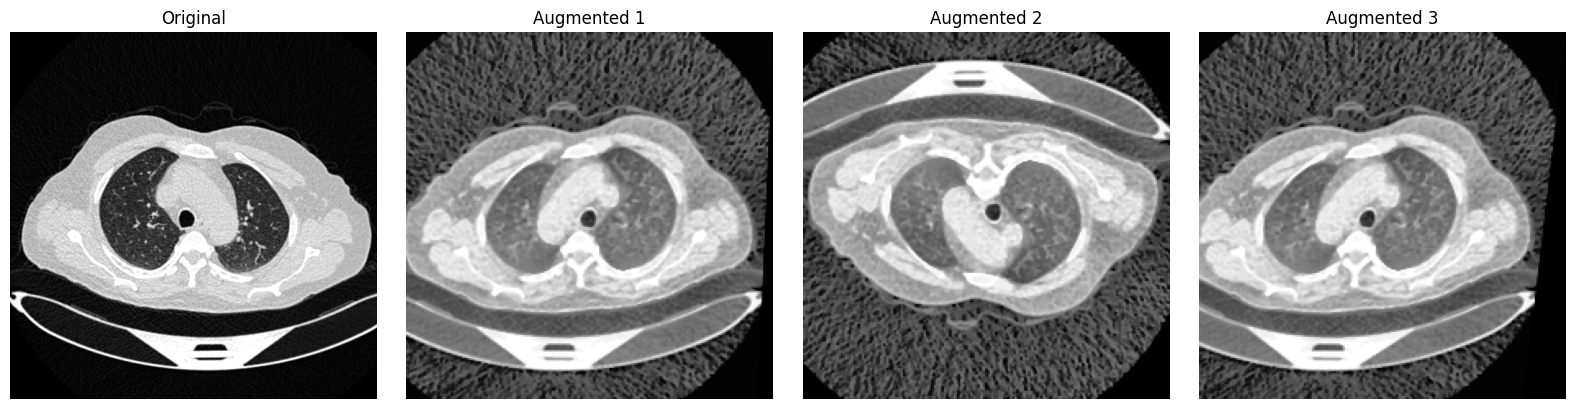

In [ ]:
sample_file = train_fp[0]
raw = cv2.imread(sample_file, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(16,4))
axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 4):
    aug = preprocess_train(raw.copy())
    axes[i].imshow(aug, cmap='gray'); axes[i].set_title(f'Augmented {i}'); axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

def load_and_preprocess(filepath, label, training):
    def _load(fp):
        fp = fp.numpy().decode('utf-8')
        img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        if training:
            img = preprocess_train(img)
        else:
            img = preprocess_eval(img)
        img = np.stack([img]*3, axis=-1)  # grayscale -> 3 channels (needed for pretrained models later)
        return img.astype('float32')

    img = tf.py_function(_load, [filepath], tf.float32)
    img.set_shape((224, 224, 3))
    label = tf.one_hot(label, depth=3)
    return img, label

def make_dataset(filepaths, labels, training=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths))
    ds = ds.map(lambda fp, lb: load_and_preprocess(fp, lb, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_fp, train_lb, training=True)
val_ds   = make_dataset(val_fp, val_lb, training=False)
test_ds  = make_dataset(test_fp, test_lb, training=False)

Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32, 3)


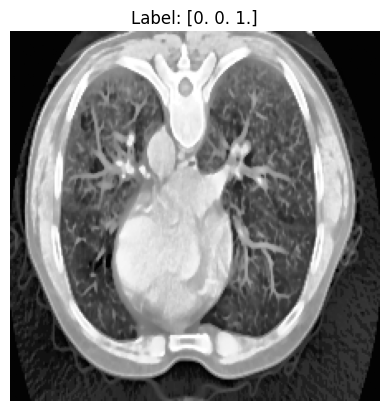

In [ ]:
for images, labels in train_ds.take(1):
    print("Batch images shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    plt.imshow(images[0])
    plt.title(f"Label: {labels[0].numpy()}")
    plt.axis('off')
    plt.show()

In [ ]:
from tensorflow.keras import layers, models

def build_enhanced_cnn(input_shape=(224,224,3), num_classes=3):
    model = models.Sequential([
        # Layer 1
        layers.Conv2D(64, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Layer 2
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Layer 3
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Dropout(0.4),

        # Layer 4 (extra dropout, as paper describes)
        layers.Dropout(0.2),

        # Layer 5
        layers.Flatten(),

        # Layer 6
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        # Layer 7
        layers.Dense(128, activation='relu'),

        # Layer 8
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_enhanced_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,214,211 (84.74 MB)

 Trainable params: 22,214,211 (84.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = build_enhanced_cnn()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=train_lb
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.8785796105383734), 1: np.float64(3.0436507936507935), 2: np.float64(0.6522108843537415)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 538ms/step - accuracy: 0.3181 - loss: 1.3312 - precision: 0.2957 - recall: 0.0443 - val_accuracy: 0.2000 - val_loss: 1.1009 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.3116 - loss: 1.0875 - precision: 1.0000 - recall: 0.0039 - val_accuracy: 0.6091 - val_loss: 1.0312 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step - accuracy: 0.5424 - loss: 1.0345 - precision: 0.6905 - recall: 0.1134 - val_accuracy: 0.4818 - val_loss: 1.0580 - val_precision: 0.7143 - val_recall: 0.0455
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - accuracy: 0.4746 - loss: 1.0139 - precision: 0.6849 - recall: 0.1956 - val_accuracy: 0.5909 - val_loss: 0.8865 - val_precision: 0.6224 - val_recall: 0.5545
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 348ms/step - accuracy: 0.5306 - loss: 0.9708 - precision: 0.6855 - recall: 0.3012 - val_accuracy:

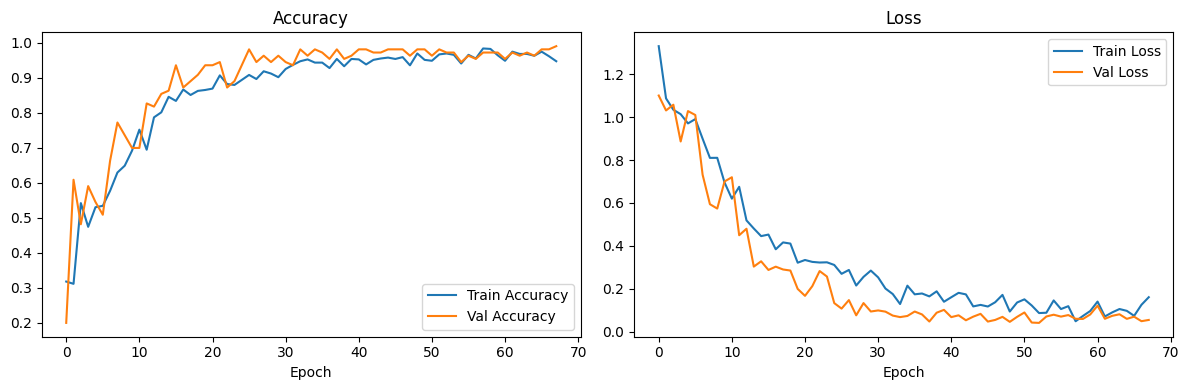

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 841ms/step - accuracy: 0.9818 - loss: 0.0722 - precision: 0.9818 - recall: 0.9818
Test Accuracy: 0.9818
Test Precision: 0.9818
Test Recall: 0.9818


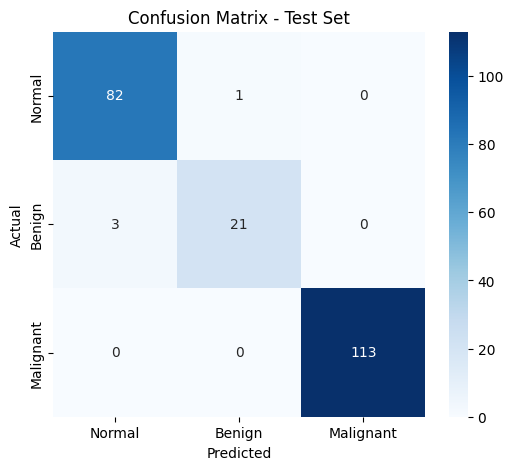

              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98        83
      Benign       0.95      0.88      0.91        24
   Malignant       1.00      1.00      1.00       113

    accuracy                           0.98       220
   macro avg       0.97      0.95      0.96       220
weighted avg       0.98      0.98      0.98       220



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
class_names = ['Normal', 'Benign', 'Malignant']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

def build_vgg16(input_shape=(224,224,3), num_classes=3):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # freeze pretrained layers (as paper did)

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

vgg_model = build_vgg16()
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,170,755 (80.76 MB)

 Trainable params: 6,456,067 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnetb0(input_shape=(224,224,3), num_classes=3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

effnet_model = build_efficientnetb0()
effnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
def preprocess_train_raw(img):
    img = enhance_image(img)
    img = augment_image(img)
    img = cv2.resize(img, (224,224))
    return img.astype('float32')  # NOTE: no /255 here

def preprocess_eval_raw(img):
    img = enhance_image(img)
    img = cv2.resize(img, (224,224))
    return img.astype('float32')

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

def load_and_preprocess_pretrained(filepath, label, training, preprocess_fn):
    def _load(fp):
        fp = fp.numpy().decode('utf-8')
        img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        img = preprocess_train_raw(img) if training else preprocess_eval_raw(img)
        img = np.stack([img]*3, axis=-1)
        img = preprocess_fn(img)  # model-specific normalization
        return img.astype('float32')

    img = tf.py_function(_load, [filepath], tf.float32)
    img.set_shape((224, 224, 3))
    label = tf.one_hot(label, depth=3)
    return img, label

def make_dataset_pretrained(filepaths, labels, preprocess_fn, training=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths))
    ds = ds.map(lambda fp, lb: load_and_preprocess_pretrained(fp, lb, training, preprocess_fn),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Separate datasets per model
train_ds_vgg = make_dataset_pretrained(train_fp, train_lb, vgg_preprocess, training=True)
val_ds_vgg   = make_dataset_pretrained(val_fp, val_lb, vgg_preprocess, training=False)

train_ds_eff = make_dataset_pretrained(train_fp, train_lb, eff_preprocess, training=True)
val_ds_eff   = make_dataset_pretrained(val_fp, val_lb, eff_preprocess, training=False)

In [ ]:
vgg_model = build_vgg16()
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

history_vgg = vgg_model.fit(train_ds_vgg, validation_data=val_ds_vgg, epochs=100,
                             class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 603ms/step - accuracy: 0.5750 - loss: 21.6791 - precision: 0.5750 - recall: 0.5750 - val_accuracy: 0.8273 - val_loss: 5.5922 - val_precision: 0.8273 - val_recall: 0.8273
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 496ms/step - accuracy: 0.7223 - loss: 9.8483 - precision: 0.7232 - recall: 0.7223 - val_accuracy: 0.7000 - val_loss: 4.1076 - val_precision: 0.7000 - val_recall: 0.7000
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - accuracy: 0.7731 - loss: 5.7143 - precision: 0.7728 - recall: 0.7718 - val_accuracy: 0.7545 - val_loss: 2.4684 - val_precision: 0.7545 - val_recall: 0.7545
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 477ms/step - accuracy: 0.7862 - loss: 4.2552 - precision: 0.7862 - recall: 0.7862 - val_accuracy: 0.9000 - val_loss: 1.3341 - val_precision: 0.9000 - val_recall: 0.9000
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 450ms/step - accuracy: 0.7823 - loss: 3.3600 - precision: 0.7823 - recall: 0.7823 - val_accuracy: 0.8636 - v

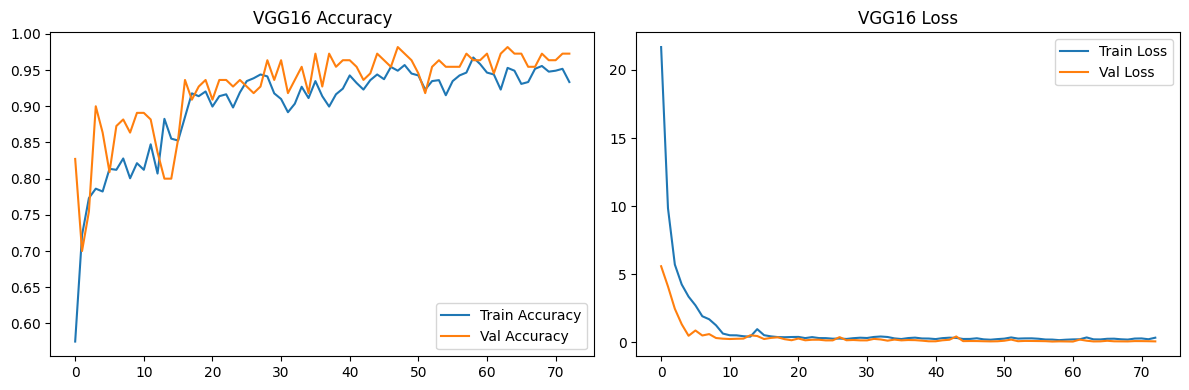

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
effnet_model = build_efficientnetb0()
effnet_model.compile(optimizer='adam', loss='categorical_crossentropy',
                      metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

history_eff = effnet_model.fit(train_ds_eff, validation_data=val_ds_eff, epochs=100,
                                class_weight=class_weights, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.6037 - loss: 0.9479 - precision: 0.6647 - recall: 0.4472 - val_accuracy: 0.6727 - val_loss: 0.6382 - val_precision: 0.7875 - val_recall: 0.5727
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 333ms/step - accuracy: 0.7301 - loss: 0.7058 - precision: 0.7893 - recall: 0.6545 - val_accuracy: 0.8455 - val_loss: 0.4568 - val_precision: 0.8511 - val_recall: 0.7273
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.6962 - loss: 0.6567 - precision: 0.7329 - recall: 0.6441 - val_accuracy: 0.8545 - val_loss: 0.3841 - val_precision: 0.8932 - val_recall: 0.8364
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.7784 - loss: 0.5609 - precision: 0.8171 - recall: 0.7458 - val_accuracy: 0.8455 - val_loss: 0.3902 - val_precision: 0.8713 - val_recall: 0.8000
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.7992 - loss: 0.5343 - precision: 0.8302 - recall: 0.7588 - val_accuracy: 0.8000 - val_loss

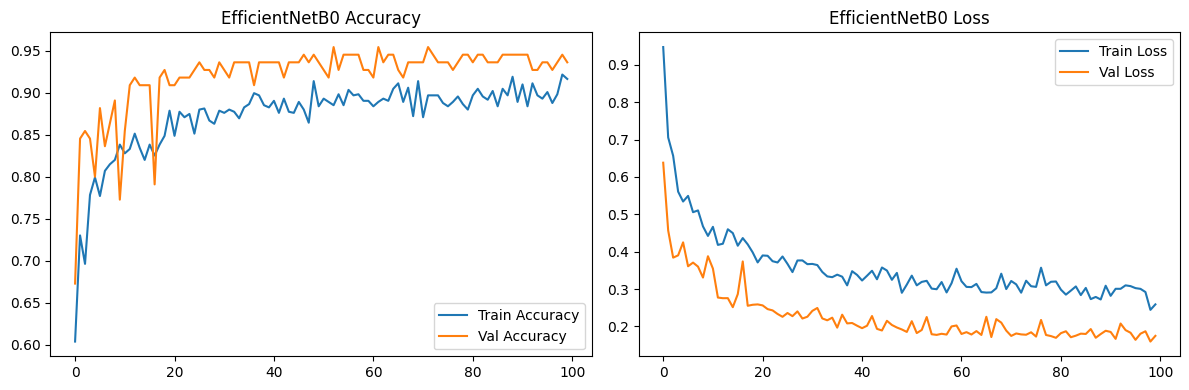

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB0 Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0 Loss'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_ds_vgg = make_dataset_pretrained(test_fp, test_lb, vgg_preprocess, training=False)
test_ds_eff = make_dataset_pretrained(test_fp, test_lb, eff_preprocess, training=False)

In [ ]:
test_loss_vgg, test_acc_vgg, test_prec_vgg, test_rec_vgg = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 — Test Accuracy: {test_acc_vgg:.4f}, Precision: {test_prec_vgg:.4f}, Recall: {test_rec_vgg:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9591 - loss: 0.1877 - precision: 0.9635 - recall: 0.9591
VGG16 — Test Accuracy: 0.9591, Precision: 0.9635, Recall: 0.9591


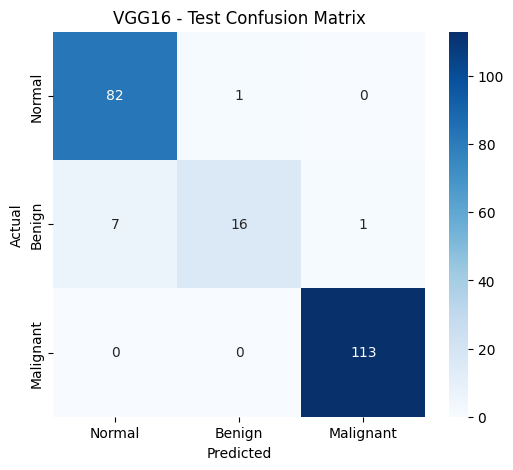

              precision    recall  f1-score   support

      Normal       0.92      0.99      0.95        83
      Benign       0.94      0.67      0.78        24
   Malignant       0.99      1.00      1.00       113

    accuracy                           0.96       220
   macro avg       0.95      0.88      0.91       220
weighted avg       0.96      0.96      0.96       220



In [ ]:
y_true_vgg, y_pred_vgg = [], []
for images, labels in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_true_vgg.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_vgg.extend(np.argmax(preds, axis=1))

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
plt.figure(figsize=(6,5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('VGG16 - Test Confusion Matrix')
plt.show()

print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

In [ ]:
test_loss_eff, test_acc_eff, test_prec_eff, test_rec_eff = effnet_model.evaluate(test_ds_eff)
print(f"EfficientNetB0 — Test Accuracy: {test_acc_eff:.4f}, Precision: {test_prec_eff:.4f}, Recall: {test_rec_eff:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9091 - loss: 0.2197 - precision: 0.9128 - recall: 0.9045
EfficientNetB0 — Test Accuracy: 0.9091, Precision: 0.9128, Recall: 0.9045


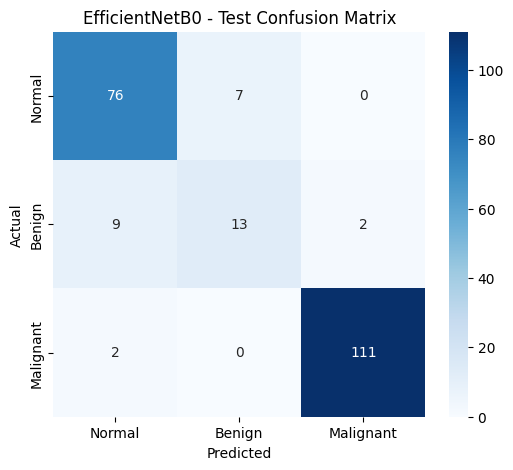

              precision    recall  f1-score   support

      Normal       0.87      0.92      0.89        83
      Benign       0.65      0.54      0.59        24
   Malignant       0.98      0.98      0.98       113

    accuracy                           0.91       220
   macro avg       0.84      0.81      0.82       220
weighted avg       0.91      0.91      0.91       220



In [ ]:
y_true_eff, y_pred_eff = [], []
for images, labels in test_ds_eff:
    preds = effnet_model.predict(images, verbose=0)
    y_true_eff.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_eff.extend(np.argmax(preds, axis=1))

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
plt.figure(figsize=(6,5))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('EfficientNetB0 - Test Confusion Matrix')
plt.show()

print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))

            Model  Test Accuracy  Precision    Recall
0    Enhanced CNN       0.981818   0.981818  0.981818
1           VGG16       0.959091   0.963470  0.959091
2  EfficientNetB0       0.909091   0.912844  0.904545


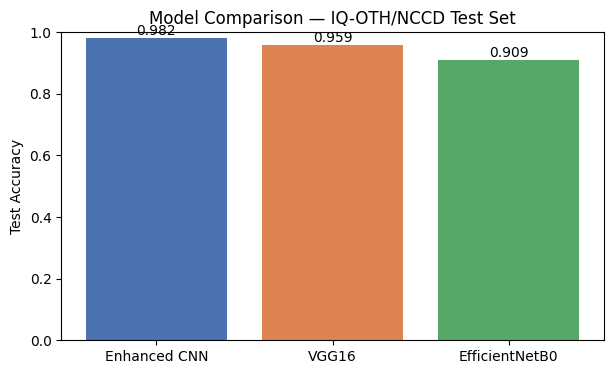

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Enhanced CNN', 'VGG16', 'EfficientNetB0'],
    'Test Accuracy': [test_acc, test_acc_vgg, test_acc_eff],
    'Precision': [test_precision, test_prec_vgg, test_prec_eff],
    'Recall': [test_recall, test_rec_vgg, test_rec_eff]
})
print(results)

plt.figure(figsize=(7,4))
plt.bar(results['Model'], results['Test Accuracy'], color=['#4C72B0','#DD8452','#55A868'])
plt.ylabel('Test Accuracy')
plt.title('Model Comparison — IQ-OTH/NCCD Test Set')
plt.ylim(0,1)
for i, v in enumerate(results['Test Accuracy']):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center')
plt.show()